In [4]:
import os
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import go3

# Global configuration
RESULTS_ROOT = "/home/atoffano/PFP_layer/results"
DATASETS = ["ATGO", "D1"]
SUBONTOLOGIES = ["BPO", "MFO", "CCO"]
SPLIT = "test"

# Output folder for saved figures
PLOTS_DIR = os.path.join(os.getcwd(), "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

# Match style from plot(1).ipynb
plt.rcParams.update({"font.size": 22, "legend.fontsize": 18})
CMAP = plt.get_cmap("tab20")
X_F, Y_F = np.meshgrid(np.arange(0.01, 1, 0.01), np.arange(0.01, 1, 0.01))
Z_F = 2 * X_F * Y_F / (X_F + Y_F)

def save_and_show(fig, filename):
    name_root, _ = os.path.splitext(filename)
    out_path = os.path.join(PLOTS_DIR, f"{name_root}.svg")
    fig.savefig(out_path, format="svg", bbox_inches="tight")
    plt.show()
    print(f"Saved plot: {out_path}")

def get_model_dirs(base_dir, dataset, name_filters=None):
    if not os.path.exists(base_dir):
        print(f"Base directory not found: {base_dir}")
        return []
    model_dirs = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]
    if name_filters:
        model_dirs = [d for d in model_dirs if any(f in d for f in name_filters)]
    return [d for d in model_dirs if dataset in d]

def get_filtered_model_dirs(results_root, dataset, model_filters=None, exclude_tokens=None):
    base_dir = os.path.join(results_root, dataset)
    model_dirs = get_model_dirs(base_dir, dataset, model_filters)
    if exclude_tokens:
        model_dirs = [d for d in model_dirs if not any(tok in d for tok in exclude_tokens)]
    return base_dir, model_dirs

def load_tsv_results(model_dirs, base_dir, split, subontology, eval_subdir, filename, required_cols, value_map, score_label=None, score_col=None, score_reduce="max"):
    results = []
    for model in model_dirs:
        eval_path = os.path.join(base_dir, model, "evaluation", f"{split}_{subontology}", eval_subdir, filename)
        if not os.path.exists(eval_path):
            continue
        try:
            df = pd.read_csv(eval_path, sep="\t")
            if not set(required_cols).issubset(df.columns):
                continue
            df = df[list(required_cols)].dropna()
            if df.empty:
                continue
            row = {"Model": model}
            for out_name, col_name in value_map.items():
                row[out_name] = df[col_name].values
            if score_label and score_col:
                row[score_label] = float(getattr(df[score_col], score_reduce)())
            results.append(row)
        except Exception as e:
            print(f"Failed to load {eval_path}: {e}")
    return results

def load_pickle_results(model_dirs, base_dir, split, subontology, eval_subdir, filename, value_map, score_label=None, score_key=None, default_score=0.0):
    results = []
    for model in model_dirs:
        eval_path = os.path.join(base_dir, model, "evaluation", f"{split}_{subontology}", eval_subdir, filename)
        if not os.path.exists(eval_path):
            continue
        try:
            with open(eval_path, "rb") as f:
                res = pickle.load(f)
            row = {"Model": model}
            for out_name, key_name in value_map.items():
                row[out_name] = res.get(key_name)
            if score_label and score_key:
                row[score_label] = float(res.get(score_key, default_score))
            results.append(row)
        except Exception as e:
            print(f"Failed to load {eval_path}: {e}")
    return results

def _add_pr_threshold_background(ax, levels=None):
    if levels is None:
        levels = np.arange(0.1, 1.0, 0.1)

    cs = ax.contour(
        X_F, Y_F, Z_F,
        levels=levels,
        colors="gray",
        linewidths=1.0,
        alpha=1,
        zorder=1
    )

    # Deterministic label anchors: shift r_lbl gradually from 0.75 to 0.5 over levels
    r_lbl_values = np.linspace(0.75, 0.90, len(levels))
    manual_positions = []
    for f, r_lbl_i in zip(levels, r_lbl_values):
        denom = (2 * r_lbl_i - f)
        if denom <= 0:
            continue
        p_lbl = (f * r_lbl_i) / denom
        if 0 <= p_lbl <= 1:
            manual_positions.append((p_lbl, r_lbl_i))

    ax.clabel(
        cs,
        levels=levels,
        manual=manual_positions,
        inline=True,
        fmt="%.1f",
        fontsize=20,
        rightside_up=True
    )

    ax.grid(True, which="major", color="lightgray", linestyle="--", linewidth=0.6, alpha=0.35)

def plot_pr_curves(results, title, save_name, score_label="FMAX", score_desc=True, legend_name_map=None):
    if not results:
        print("No valid evaluation files found.")
        return

    fig, ax = plt.subplots(figsize=(15, 15))
    _add_pr_threshold_background(ax)

    scored = []
    for row in results:
        r_arr, p_arr = _prepare_pr_arrays(row.get("Recalls"), row.get("Precisions"), endpoints=True)
        if len(p_arr) == 0 or len(r_arr) == 0:
            continue

        fmax, best_idx = _compute_fmax(r_arr, p_arr)
        aupr = _compute_aupr(r_arr, p_arr)
        display_score = float(row.get(score_label, fmax))
        model = row["Model"]
        display_name = _display_model_name(model, legend_name_map)
        scored.append((display_score, aupr, p_arr, r_arr, best_idx, display_name))

    if not scored:
        plt.close(fig)
        print("No valid precision-recall points found.")
        return

    for i, (display_score, aupr, p_arr, r_arr, best_idx, display_name) in enumerate(sorted(scored, key=lambda x: x[0], reverse=score_desc)):
        color = CMAP.colors[i % len(CMAP.colors)]
        label = f"{display_name} ({score_label}={display_score:.3f} | AUPR={aupr:.3f})"
        ax.plot(r_arr, p_arr, color=color, label=label, lw=2, zorder=500 - i)
        ax.plot(r_arr[best_idx], p_arr[best_idx], color=color, marker="o", markersize=12, mfc="none", zorder=1000 - i)
        ax.plot(r_arr[best_idx], p_arr[best_idx], color=color, marker="o", markersize=6, zorder=1000 - i)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xticks(np.arange(0.0, 1.01, 0.1))
    ax.set_yticks(np.arange(0.0, 1.01, 0.1))
    # ax.set_title(title, pad=20)
    ax.set_xlabel("Recall", labelpad=20)
    ax.set_ylabel("Precision", labelpad=20)
    leg = ax.legend(markerscale=6, loc="lower left")
    for legobj in leg.get_lines():
        legobj.set_linewidth(10.0)
    plt.tight_layout()
    save_and_show(fig, save_name)

def plot_smin_curves(results, title, save_name, legend_name_map=None):
    if not results:
        print("No valid evaluation files found.")
        return
    fig, ax = plt.subplots(figsize=(15, 15))
    for i, row in enumerate(sorted(results, key=lambda r: r["Smin"])):
        ru_arr = np.array(row.get("Remaining Uncertainty"))
        mi_arr = np.array(row.get("Misunderstanding"))
        if len(ru_arr) == 0 or len(mi_arr) == 0:
            continue
        color = CMAP.colors[i % len(CMAP.colors)]
        display_name = _display_model_name(row["Model"], legend_name_map)
        label = f"{display_name} (SMIN={row['Smin']:.3f})"
        ax.plot(ru_arr, mi_arr, color=color, label=label, lw=2, zorder=500 - i)
        best_idx = int(np.argmin(np.nan_to_num(np.sqrt(ru_arr**2 + mi_arr**2), nan=np.inf)))
        ax.plot(ru_arr[best_idx], mi_arr[best_idx], color=color, marker="o", markersize=12, mfc="none", zorder=1000 - i)
        ax.plot(ru_arr[best_idx], mi_arr[best_idx], color=color, marker="o", markersize=6, zorder=1000 - i)
    # ax.set_title(title, pad=20)
    ax.set_xlabel("Remaining Uncertainty", labelpad=20)
    ax.set_ylabel("Misinformation", labelpad=20)
    leg = ax.legend(markerscale=6, loc="upper right")
    for legobj in leg.get_lines():
        legobj.set_linewidth(10.0)
    plt.tight_layout()
    save_and_show(fig, save_name)

def _normalize_metric_key(key):
    return str(key).lower().replace("_", "").replace(" ", "")

def _prepare_pr_arrays(recalls, precisions, endpoints=False):
    recalls = np.asarray(recalls, dtype=float).reshape(-1)
    precisions = np.asarray(precisions, dtype=float).reshape(-1)
    finite_mask = np.isfinite(recalls) & np.isfinite(precisions)
    recalls = recalls[finite_mask]
    precisions = precisions[finite_mask]

    if len(recalls) == 0:
        return recalls, precisions

    order = np.argsort(recalls)
    recalls = recalls[order]
    precisions = precisions[order]

    if endpoints:
        if not (np.isclose(recalls[0], 0.0) and np.isclose(precisions[0], 1.0)):
            recalls = np.insert(recalls, 0, 0.0)
            precisions = np.insert(precisions, 0, 1.0)
        if not (np.isclose(recalls[-1], 1.0) and np.isclose(precisions[-1], 0.0)):
            recalls = np.append(recalls, 1.0)
            precisions = np.append(precisions, 0.0)

    return recalls, precisions

def _compute_fmax(recalls, precisions):
    with np.errstate(divide="ignore", invalid="ignore"):
        f_scores = 2 * recalls * precisions / (recalls + precisions)
    f_scores = np.nan_to_num(f_scores, nan=0.0)
    best_idx = int(np.argmax(f_scores))
    return float(f_scores[best_idx]), best_idx

def _compute_aupr(recalls, precisions):
    if len(recalls) == 0:
        return float("nan")
    return float(np.trapz(precisions, recalls))

def get_selected_model_dirs(results_root, dataset, selected_model_dirs=None):
    base_dir = os.path.join(results_root, dataset)
    if not os.path.exists(base_dir):
        print(f"Base directory not found: {base_dir}")
        return base_dir, []

    configured = (selected_model_dirs or {}).get(dataset, [])
    if not configured:
        print(f"No explicit model directories configured for dataset: {dataset}")
        return base_dir, []

    existing = [d for d in configured if os.path.isdir(os.path.join(base_dir, d))]
    missing = [d for d in configured if d not in existing]
    for d in missing:
        print(f"Model directory not found, skipped: {os.path.join(base_dir, d)}")
    return base_dir, existing

def _display_model_name(model, legend_name_map=None):
    if legend_name_map and model in legend_name_map:
        return legend_name_map[model]
    return model.split("GNN_")[-1]

def run_plots_for_combo(dataset, subontology, split=SPLIT, results_root=RESULTS_ROOT, selected_model_dirs=None, legend_name_map=None):
    base_dir, model_dirs = get_selected_model_dirs(results_root, dataset, selected_model_dirs)
    print(f"[{dataset} | {subontology}] models selected: {len(model_dirs)}")
    if not model_dirs:
        return

    cafa_pr = load_tsv_results(
        model_dirs=model_dirs,
        base_dir=base_dir,
        split=split,
        subontology=subontology,
        eval_subdir="cafa-eval",
        filename="evaluation_all.tsv",
        required_cols=["rc", "pr", "f"],
        value_map={"Precisions": "pr", "Recalls": "rc"},
        score_label="Fmax",
        score_col="f",
        score_reduce="max"
    )
    plot_pr_curves(
        results=cafa_pr,
        title=f"Precision-Recall Curves - {dataset} - {split} - {subontology}",
        save_name=f"pr_cafa_{dataset}_{split}_{subontology}.png",
        score_label="Fmax",
        score_desc=True,
        legend_name_map=legend_name_map
    )

    cafa_smin = load_tsv_results(
        model_dirs=model_dirs,
        base_dir=base_dir,
        split=split,
        subontology=subontology,
        eval_subdir="cafa-eval",
        filename="evaluation_all.tsv",
        required_cols=["ru", "mi", "s"],
        value_map={"Remaining Uncertainty": "ru", "Misunderstanding": "mi"},
        score_label="Smin",
        score_col="s",
        score_reduce="min"
    )
    plot_smin_curves(
        results=cafa_smin,
        title=f"Smin Curves - {dataset} - {split} - {subontology}",
        save_name=f"smin_cafa_{dataset}_{split}_{subontology}.png",
        legend_name_map=legend_name_map
    )

    beprof_pr = load_pickle_results(
        model_dirs=model_dirs,
        base_dir=base_dir,
        split=split,
        subontology=subontology,
        eval_subdir="beprof-eval",
        filename="beprof_eval_results.pkl",
        value_map={"Precisions": "precisions", "Recalls": "recalls"},
        score_label="Fmax",
        score_key="result_fmax",
        default_score=0.0
    )
    plot_pr_curves(
        results=beprof_pr,
        title=f"Precision-Recall Curves - {dataset} - {split} - {subontology}",
        save_name=f"pr_beprof_{dataset}_{split}_{subontology}.png",
        score_label="Fmax",
        score_desc=True,
        legend_name_map=legend_name_map
    )

    beprof_smin = load_pickle_results(
        model_dirs=model_dirs,
        base_dir=base_dir,
        split=split,
        subontology=subontology,
        eval_subdir="beprof-eval",
        filename="beprof_eval_results.pkl",
        value_map={"Remaining Uncertainty": "ru_values", "Misunderstanding": "mi_values"},
        score_label="Smin",
        score_key="result_smin",
        default_score=np.inf
    )
    plot_smin_curves(
        results=beprof_smin,
        title=f"Smin Curves - {dataset} - {split} - {subontology}",
        save_name=f"smin_beprof_{dataset}_{split}_{subontology}.png",
        legend_name_map=legend_name_map
    )

    beprof_w_pr = load_pickle_results(
        model_dirs=model_dirs,
        base_dir=base_dir,
        split=split,
        subontology=subontology,
        eval_subdir="beprof-eval",
        filename="beprof_eval_results.pkl",
        value_map={"Precisions": "icprecisions", "Recalls": "icrecalls"}
    )
    plot_pr_curves(
        results=beprof_w_pr,
        title=f"Weighted Precision-Recall Curves - {dataset} - {split} - {subontology}",
        save_name=f"pr_weighted_beprof_{dataset}_{split}_{subontology}.png",
        score_label="FMAX_W",
        score_desc=True,
        legend_name_map=legend_name_map
    )

def plot_beprof_pr_subplots(dataset, split=SPLIT, results_root=RESULTS_ROOT, selected_model_dirs=None, legend_name_map=None, subontologies=("BPO", "MFO", "CCO")):
    base_dir, model_dirs = get_selected_model_dirs(results_root, dataset, selected_model_dirs)
    print(f"[{dataset}] models selected: {len(model_dirs)}")
    if not model_dirs:
        return

    ordered_subontologies = ["BPO", "MFO", "CCO"]
    results_by_sub = {}
    all_display_names = []

    for subontology in ordered_subontologies:
        rows = load_pickle_results(
            model_dirs=model_dirs,
            base_dir=base_dir,
            split=split,
            subontology=subontology,
            eval_subdir="beprof-eval",
            filename="beprof_eval_results.pkl",
            value_map={"Precisions": "precisions", "Recalls": "recalls"},
            score_label="Fmax",
            score_key="result_fmax",
            default_score=0.0,
        )
        results_by_sub[subontology] = rows
        for row in rows:
            all_display_names.append(_display_model_name(row["Model"], legend_name_map))

    unique_names = sorted(set(all_display_names))
    color_by_name = {name: CMAP.colors[i % len(CMAP.colors)] for i, name in enumerate(unique_names)}

    fig, axes = plt.subplots(1, 3, figsize=(30, 10), sharex=True, sharey=True)
    legend_handles = {}

    for ax, subontology in zip(axes, ordered_subontologies):
        _add_pr_threshold_background(ax)
        rows = results_by_sub.get(subontology, [])

        scored = []
        for row in rows:
            # no endpoints as requested
            r_arr, p_arr = _prepare_pr_arrays(row.get("Recalls"), row.get("Precisions"), endpoints=False)
            if len(r_arr) == 0 or len(p_arr) == 0:
                continue
            fmax, best_idx = _compute_fmax(r_arr, p_arr)
            display_score = float(row.get("Fmax", fmax))
            display_name = _display_model_name(row["Model"], legend_name_map)
            scored.append((display_score, p_arr, r_arr, best_idx, display_name))

        for i, (display_score, p_arr, r_arr, best_idx, display_name) in enumerate(sorted(scored, key=lambda x: x[0], reverse=True)):
            color = color_by_name.get(display_name, CMAP.colors[i % len(CMAP.colors)])
            label = f"{display_name} (Fmax={display_score:.3f})"  # AUPR removed
            line, = ax.plot(r_arr, p_arr, color=color, label=label, lw=2, zorder=500 - i)
            ax.plot(r_arr[best_idx], p_arr[best_idx], color=color, marker="o", markersize=10, mfc="none", zorder=1000 - i)
            ax.plot(r_arr[best_idx], p_arr[best_idx], color=color, marker="o", markersize=5, zorder=1000 - i)
            if display_name not in legend_handles:
                legend_handles[display_name] = line

        ax.set_title(subontology)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_xticks(np.arange(0.0, 1.01, 0.1))
        ax.set_yticks(np.arange(0.0, 1.01, 0.1))
        ax.set_xlabel("Recall", labelpad=12)

        # Independent legend per subplot (bottom-left), keep Fmax labels
        sub_leg = ax.legend(loc="lower left", markerscale=3, frameon=True)
        for legobj in sub_leg.get_lines():
            legobj.set_linewidth(4.0)

    axes[0].set_ylabel("Precision", labelpad=12)

    # Keep global legend as-is
    if legend_handles:
        fig.legend(
            list(legend_handles.values()),
            list(legend_handles.keys()),
            loc="lower center",
            ncol=min(6, max(1, len(legend_handles))),
            bbox_to_anchor=(0.5, 0),
        )

    plt.tight_layout(rect=(0, 0.08, 1, 1))
    save_and_show(fig, f"pr_beprof_{dataset}_{split}_BPO_MFO_CCO.svg")

def run_all_beprof_pr_subplots(datasets, subontologies=None, split=SPLIT, results_root=RESULTS_ROOT, selected_model_dirs=None, legend_name_map=None):
    for dataset in datasets:
        plot_beprof_pr_subplots(
            dataset=dataset,
            split=split,
            results_root=results_root,
            selected_model_dirs=selected_model_dirs,
            legend_name_map=legend_name_map,
            subontologies=("BPO", "MFO", "CCO"),
        )


No explicit model directories configured for dataset: ATGO
[ATGO] models selected: 0
[D1] models selected: 11


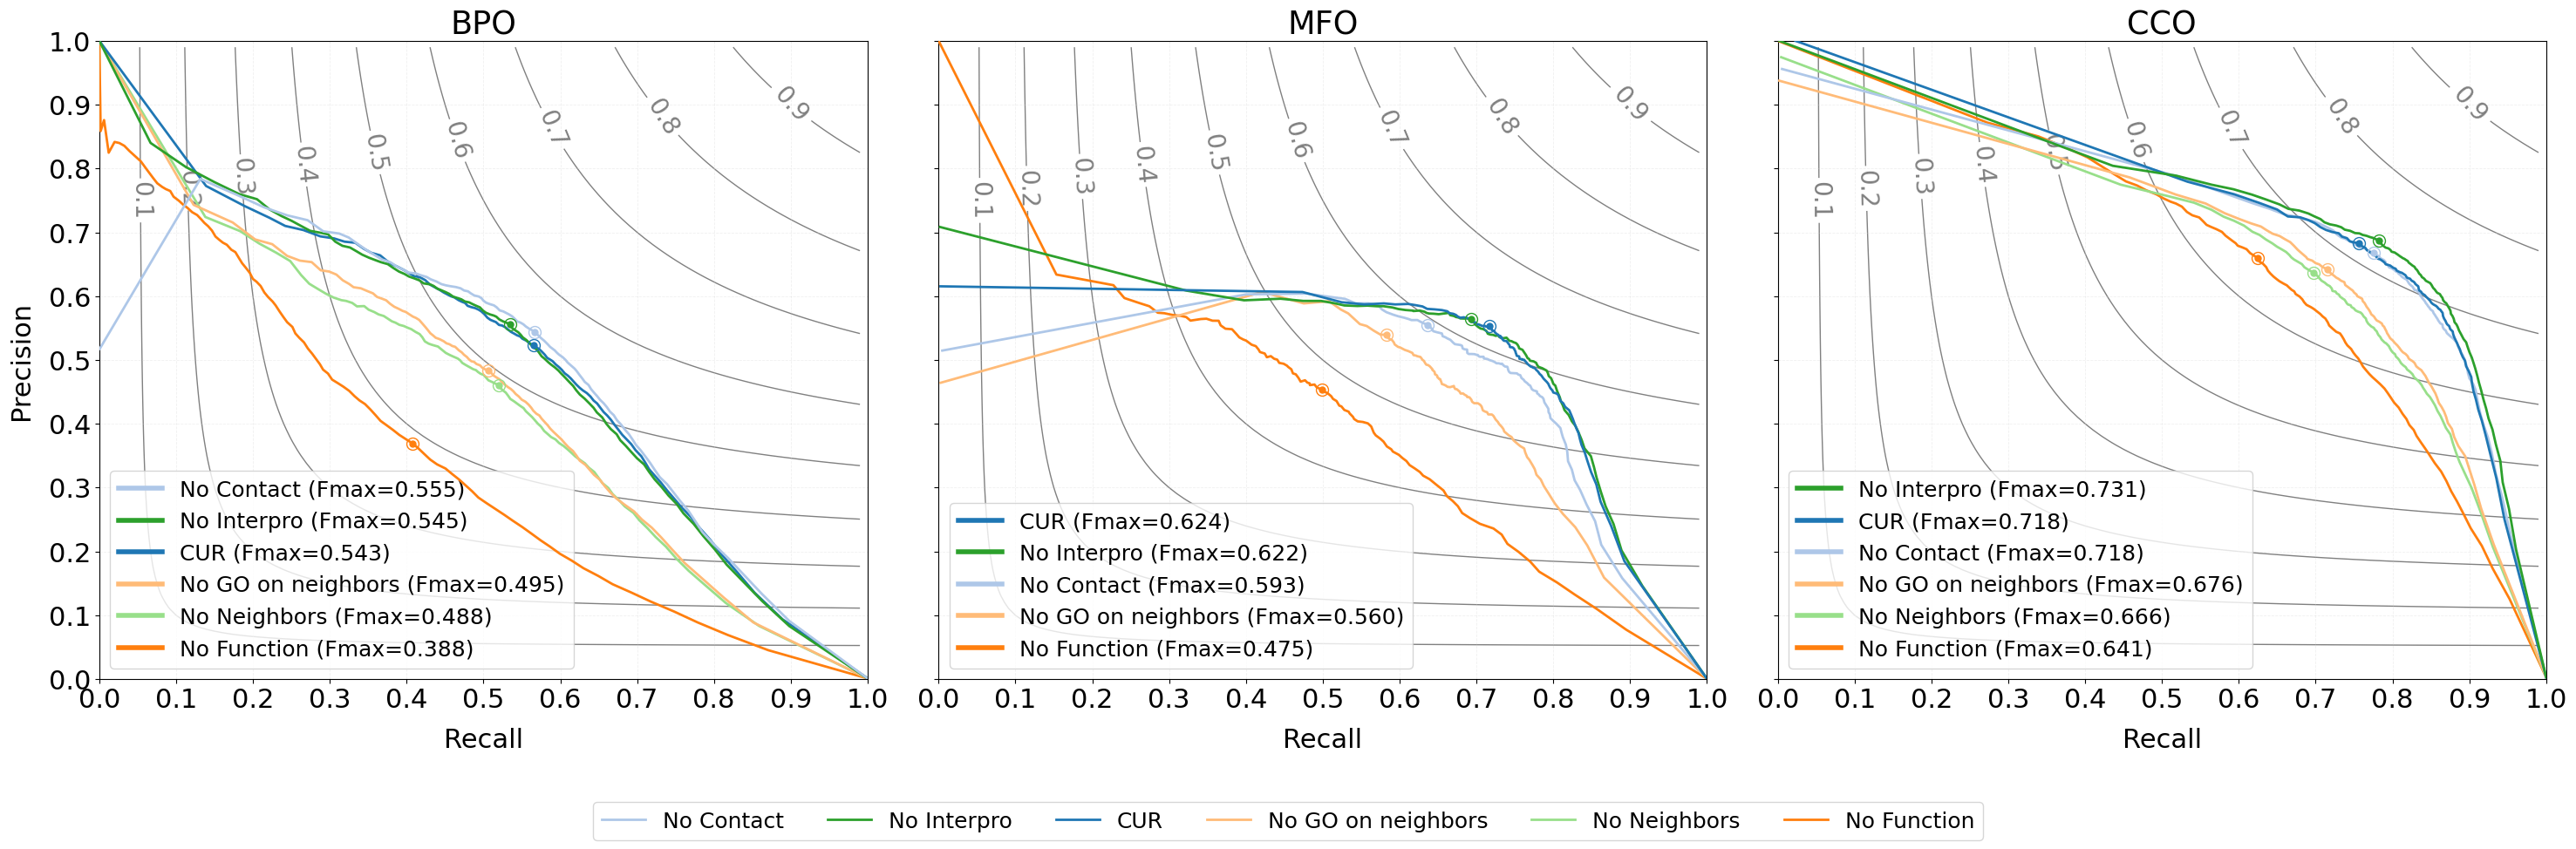

Saved plot: /home/atoffano/PFP_layer/notebooks/plots/pr_beprof_D1_test_BPO_MFO_CCO.svg


In [13]:
# Explicit model directories per dataset (exact folder names)
SELECTED_MODEL_DIRS = {
    # "ATGO": [
    # ],
    "D1": [
       "20260214_100017_D1_2024_01_GNN_CONTACT_ATTR_STRINGDB_CUR", #MFO
        "20260214_105025_D1_2024_01_GNN_CONTACT_ATTR_STRINGDB_CUR", #CCO
        "20260214_110347_D1_2024_01_GNN_CONTACT_ATTR_STRINGDB_CUR", #BPO
        # "20260214_110603_D1_2024_01_GNN_CONTACT_ATTR_STRINGDB", #CCO
        # "20260214_115223_D1_2024_01_GNN_CONTACT_ATTR_STRINGDB", #BPO
        # "20260209_082957_D1_2024_01_GNN_CONTACT_ATTR_STRINGDB", # MFO
        "20260216_111908_D1_2024_01_GNN_DEL_CONTACT_CUR", # ALL 3
        "20260216_113910_D1_2024_01_GNN_DEL_NOFUNC_CUR", #BPO
        "20260216_114356_D1_2024_01_GNN_DEL_NOFUNC_CUR", #CCO
        "20260217_132643_D1_2024_01_GNN_DEL_NOFUNC_CUR", #MFO
        "20260217_132643_D1_2024_01_GNN_DEL_NOGO_CUR", # ALL 3
        "20260217_132643_D1_2024_01_GNN_DEL_NOIPR_CUR", # ALL 3
        "20260217_133248_D1_2024_01_GNN_DEL_NOSYS_CUR", # BPO
        "20260217_133341_D1_2024_01_GNN_DEL_NOSYS_CUR", # CCO
        # "20260217_133924_D1_2024_01_GNN_DEL_NOSYS_CUR", # MFO

    ],
}

# Optional display names for legend (key = exact model dir name)
LEGEND_NAME_MAP = {
       "20260214_100017_D1_2024_01_GNN_CONTACT_ATTR_STRINGDB_CUR": "CUR", #MFO
        "20260214_105025_D1_2024_01_GNN_CONTACT_ATTR_STRINGDB_CUR": "CUR", #CCO
        "20260214_110347_D1_2024_01_GNN_CONTACT_ATTR_STRINGDB_CUR": "CUR", #BPO
        # "20260214_110603_D1_2024_01_GNN_CONTACT_ATTR_STRINGDB": "EXP", #CCO
        # "20260214_115223_D1_2024_01_GNN_CONTACT_ATTR_STRINGDB": "EXP", #BPO
        "20260216_111908_D1_2024_01_GNN_DEL_CONTACT_CUR": "No Contact", # ALL 3
        "20260216_113910_D1_2024_01_GNN_DEL_NOFUNC_CUR": "No Function", #BPO
        "20260216_114356_D1_2024_01_GNN_DEL_NOFUNC_CUR": "No Function", #CCO
        "20260217_132643_D1_2024_01_GNN_DEL_NOFUNC_CUR": "No Function", #MFO
        "20260217_132643_D1_2024_01_GNN_DEL_NOGO_CUR": "No GO on neighbors", # ALL 3
        "20260217_132643_D1_2024_01_GNN_DEL_NOIPR_CUR": "No Interpro", # ALL 3
        "20260217_133248_D1_2024_01_GNN_DEL_NOSYS_CUR": "No Neighbors", # BPO
        "20260217_133341_D1_2024_01_GNN_DEL_NOSYS_CUR": "No Neighbors", # CCO
        # "20260217_133924_D1_2024_01_GNN_DEL_NOSYS_CUR": "No Neighbors", # MFO
}

# Fix colors to 
run_all_beprof_pr_subplots(
    datasets=DATASETS,
    subontologies=["BPO", "MFO", "CCO"],
    split=SPLIT,
    results_root=RESULTS_ROOT,
    selected_model_dirs=SELECTED_MODEL_DIRS,
    legend_name_map=LEGEND_NAME_MAP,
)

No explicit model directories configured for dataset: ATGO
[ATGO] models selected: 0
[D1] models selected: 18


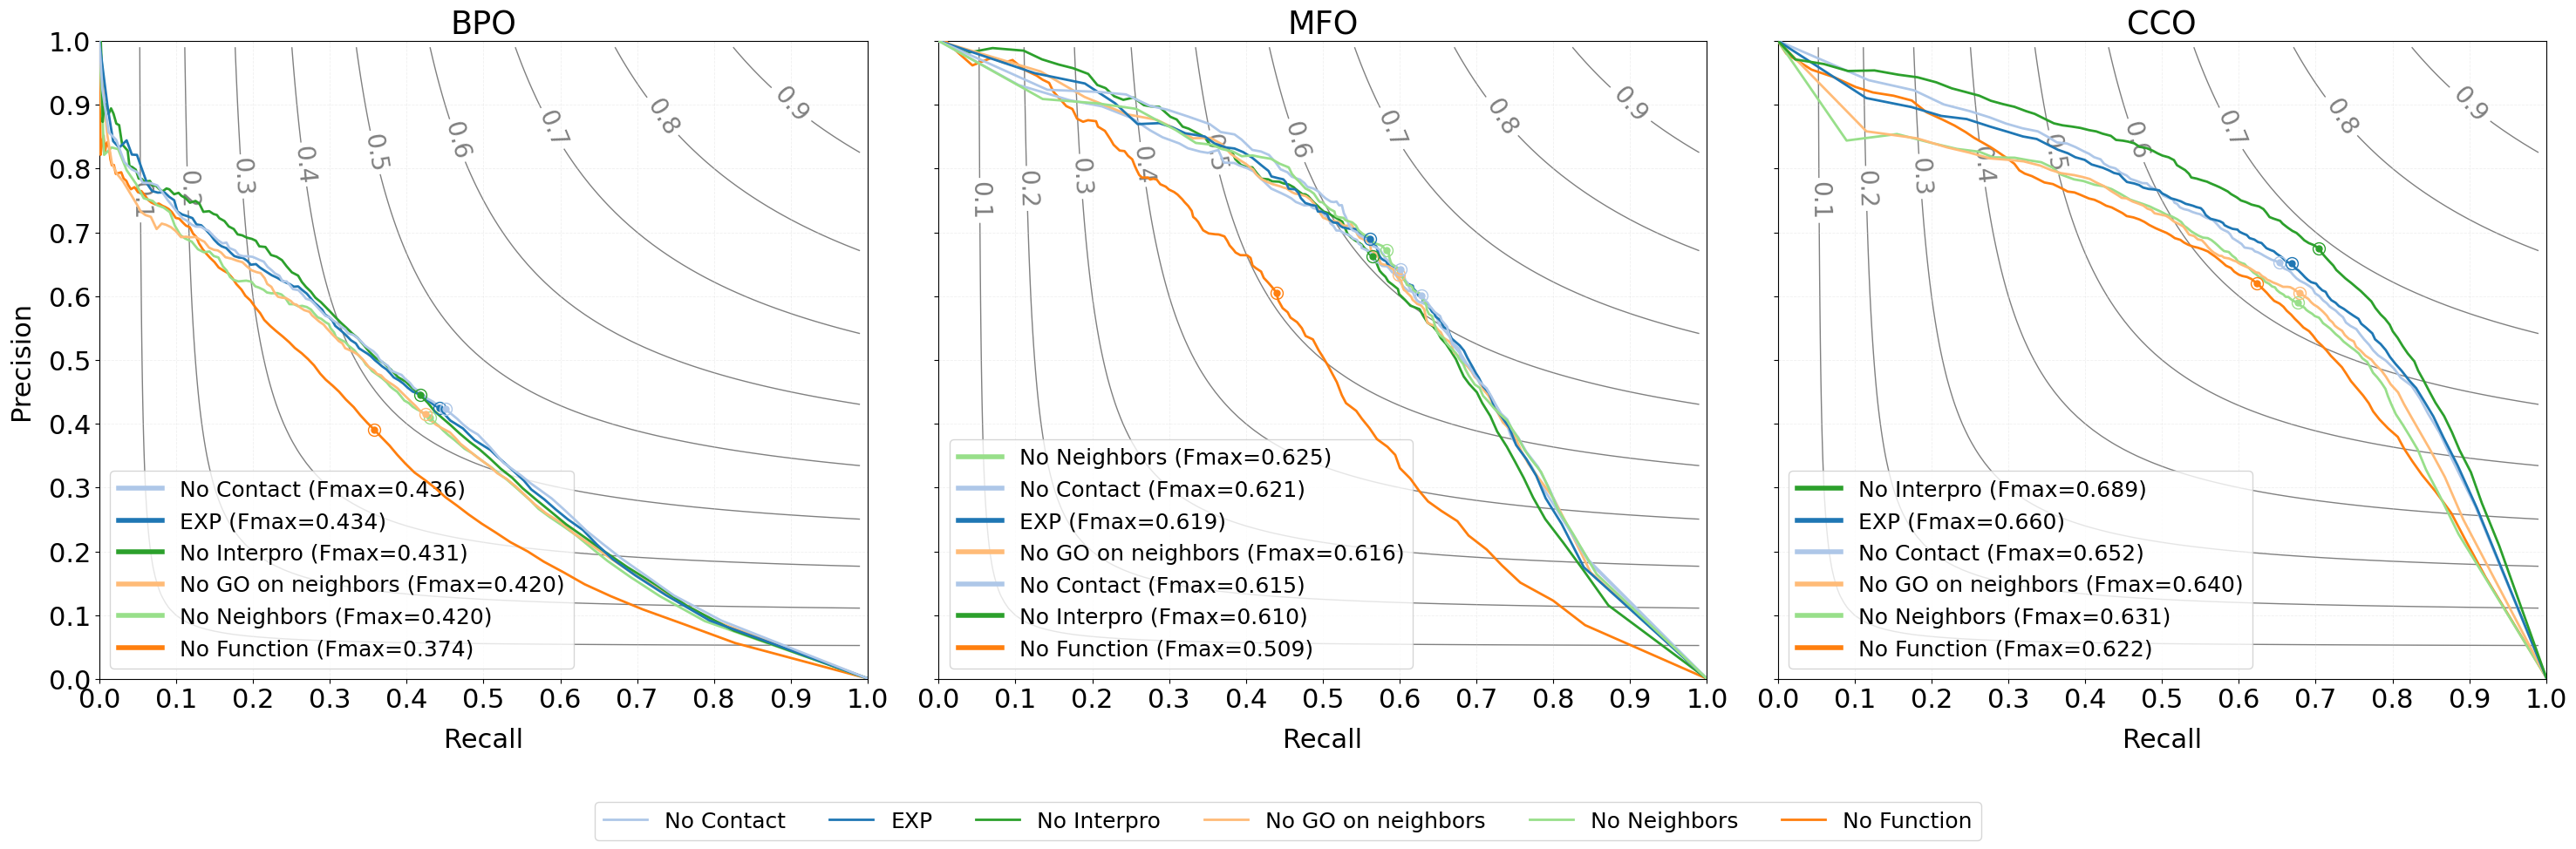

Saved plot: /home/atoffano/PFP_layer/notebooks/plots/pr_beprof_D1_test_BPO_MFO_CCO.svg


In [14]:
# EXP models
SELECTED_MODEL_DIRS = {
    "D1": [
        "20260214_110603_D1_2024_01_GNN_CONTACT_ATTR_STRINGDB", #CCO
        "20260214_115223_D1_2024_01_GNN_CONTACT_ATTR_STRINGDB", #BPO
        "20260209_082957_D1_2024_01_GNN_CONTACT_ATTR_STRINGDB", # MFO
        "20260209_092916_D1_2024_01_GNN_DEL_NOSYS", # MFO
        "20260214_100131_D1_2024_01_GNN_DEL_NOFUNC", #BPO
        "20260214_101403_D1_2024_01_GNN_DEL_NOSYS", # CCO
        "20260214_105613_D1_2024_01_GNN_DEL_NOFUNC", #CCO
        "20260209_082957_D1_2024_01_GNN_DEL_NOFUNC", # MFO
        "20260214_105749_D1_2024_01_GNN_DEL_NOIPR", #BPO
        "20260214_110857_D1_2024_01_GNN_DEL_CONTACT", #BPO
        "20260209_092916_D1_2024_01_GNN_DEL_NOIPR", # MFO
        # "20260214_111909_D1_2024_01_GNN_DEL_NOIPR", #CCO --duped ?
        "20260216_082607_D1_2024_01_GNN_DEL_NOIPR", #CCO --duped ?
        "20260214_120034_D1_2024_01_GNN_DEL_NOGO", #BPO
        "20260214_120934_D1_2024_01_GNN_DEL_NOGO", #CCO
        "20260209_084736_D1_2024_01_GNN_DEL_NOGO", # MFO
        "20260214_120952_D1_2024_01_GNN_DEL_NOSYS", #BPO
        "20260216_082607_D1_2024_01_GNN_DEL_CONTACT", #MFO, CCO
        "20260209_082957_D1_2024_01_GNN_DEL_CONTACT", # MFO


    ],
}
LEGEND_NAME_MAP = {
        "20260214_110603_D1_2024_01_GNN_CONTACT_ATTR_STRINGDB": "EXP", #CCO
        "20260214_115223_D1_2024_01_GNN_CONTACT_ATTR_STRINGDB": "EXP", #BPO
        "20260209_082957_D1_2024_01_GNN_CONTACT_ATTR_STRINGDB": "EXP", # MFO
        "20260209_092916_D1_2024_01_GNN_DEL_NOSYS": "No Neighbors", # MFO
        "20260214_100131_D1_2024_01_GNN_DEL_NOFUNC": "No Function", #BPO
        "20260214_101403_D1_2024_01_GNN_DEL_NOSYS": "No Neighbors", # CCO
        "20260214_105613_D1_2024_01_GNN_DEL_NOFUNC": "No Function", #CCO
        "20260209_082957_D1_2024_01_GNN_DEL_NOFUNC": "No Function", # MFO
        "20260214_105749_D1_2024_01_GNN_DEL_NOIPR": "No Interpro", #BPO
        "20260214_110857_D1_2024_01_GNN_DEL_CONTACT": "No Contact", #BPO
        "20260209_092916_D1_2024_01_GNN_DEL_NOIPR": "No Interpro", # MFO
        "20260214_111909_D1_2024_01_GNN_DEL_NOIPR": "No Interpro", #CCO --duped ?
        "20260216_082607_D1_2024_01_GNN_DEL_NOIPR": "No Interpro", #CCO --duped ?
        "20260214_120034_D1_2024_01_GNN_DEL_NOGO": "No GO on neighbors", #BPO
        "20260214_120934_D1_2024_01_GNN_DEL_NOGO": "No GO on neighbors", #CCO
        "20260209_084736_D1_2024_01_GNN_DEL_NOGO": "No GO on neighbors", # MFO
        "20260214_120952_D1_2024_01_GNN_DEL_NOSYS": "No Neighbors", #BPO
        "20260216_082607_D1_2024_01_GNN_DEL_CONTACT": "No Contact", #MFO, CCO
        "20260209_082957_D1_2024_01_GNN_DEL_CONTACT": "No Contact", # MFO

}

run_all_beprof_pr_subplots(
    datasets=DATASETS,
    subontologies=["BPO", "MFO", "CCO"],
    split=SPLIT,
    results_root=RESULTS_ROOT,
    selected_model_dirs=SELECTED_MODEL_DIRS,
    legend_name_map=LEGEND_NAME_MAP,
)

In [8]:
import os
import pickle
import pandas as pd
import numpy as np

# CUR models only
SELECTED_MODEL_DIRS = {
    "D1": [
        "20260214_100017_D1_2024_01_GNN_CONTACT_ATTR_STRINGDB_CUR",  # MFO
        "20260214_105025_D1_2024_01_GNN_CONTACT_ATTR_STRINGDB_CUR",  # CCO
        "20260214_110347_D1_2024_01_GNN_CONTACT_ATTR_STRINGDB_CUR",  # BPO
        "20260214_110603_D1_2024_01_GNN_CONTACT_ATTR_STRINGDB", #CCO
        "20260214_115223_D1_2024_01_GNN_CONTACT_ATTR_STRINGDB", #BPO
        "20260209_082957_D1_2024_01_GNN_CONTACT_ATTR_STRINGDB", # MFO
    ]
}

def _pick_metric(d, keys, default=np.nan):
    for k in keys:
        if k in d and d[k] is not None:
            try:
                return float(d[k])
            except Exception:
                return d[k]
    return default

rows = []
for dataset, model_dirs in SELECTED_MODEL_DIRS.items():
    base_dir = os.path.join(RESULTS_ROOT, dataset)

    for model in model_dirs:
        found_any = False
        for subontology in SUBONTOLOGIES:
            pkl_path = os.path.join(
                base_dir,
                model,
                "evaluation",
                f"{SPLIT}_{subontology}",
                "beprof-eval",
                "beprof_eval_results.pkl",
            )
            if not os.path.exists(pkl_path):
                continue

            found_any = True
            with open(pkl_path, "rb") as f:
                res = pickle.load(f)

            rows.append(
                {
                    "Dataset": dataset,
                    "Subontology": subontology,
                    "Model": model,
                    "result_fmax": _pick_metric(res, ["result_fmax", "fmax"]),
                    "result_smin": _pick_metric(res, ["result_smin", "smin"]),
                    "result_aupr": _pick_metric(res, ["result_aupr", "aupr"]),
                    "ic_aupr": _pick_metric(res, ["result_icaupr", "result_iaupr", "ic_aupr", "iaupr"]),
                }
            )

        if not found_any:
            rows.append(
                {
                    "Dataset": dataset,
                    "Subontology": None,
                    "Model": model,
                    "result_fmax": np.nan,
                    "result_smin": np.nan,
                    "result_aupr": np.nan,
                    "ic_aupr": np.nan,
                }
            )

metrics_df = pd.DataFrame(rows)

if metrics_df.empty:
    print("No beprof_eval_results.pkl files found.")
else:
    metrics_df = metrics_df.sort_values(["Dataset", "Subontology", "Model"]).reset_index(drop=True)
    display(metrics_df)

,Dataset,Subontology,Model,result_fmax,result_smin,result_aupr,ic_aupr
0,D1,BPO,20260214_110347_D1_2024_01_GNN_CONTACT_ATTR_ST...,0.543355,27.693124,0.510065,0.437761
1,D1,BPO,20260214_115223_D1_2024_01_GNN_CONTACT_ATTR_ST...,0.433564,32.087573,0.378069,0.308367
2,D1,CCO,20260214_105025_D1_2024_01_GNN_CONTACT_ATTR_ST...,0.717846,8.343258,0.729157,0.643192
3,D1,CCO,20260214_110603_D1_2024_01_GNN_CONTACT_ATTR_ST...,0.659964,8.968838,0.687858,0.556232
4,D1,MFO,20260209_082957_D1_2024_01_GNN_CONTACT_ATTR_ST...,0.619311,7.606308,0.628728,0.598986
5,D1,MFO,20260214_100017_D1_2024_01_GNN_CONTACT_ATTR_ST...,0.624102,10.196146,0.512309,0.516318
